In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re
import os

pd.set_option('display.max_colwidth', 80)

DATA_PATH = os.path.join(os.path.dirname(os.getcwd()), 'pdf_scripts', 'extracted_pdf_features.json')
# If running from pdf_scripts/ directly:
if not os.path.exists(DATA_PATH):
    DATA_PATH = 'extracted_pdf_features.json'

with open(DATA_PATH) as f:
    raw = json.load(f)

print(f'Loaded {len(raw)} patients')

Loaded 373 patients


In [2]:
# ── Flatten to DataFrame ────────────────────────────────────────────────────
FEATURES = [
    'Age', 'Sex_Female', 'SeizureFreqTrajectory', 'RiskFactors', 'SeizureType',
    'drug_clobazam', 'drug_clonazepam', 'drug_valproate', 'drug_ethosuximide',
    'drug_levetiracetam', 'drug_lamotrigine', 'drug_phenobarbital',
    'drug_phenytoin', 'drug_topiramate', 'drug_carbamazepine',
]
DRUGS = [f for f in FEATURES if f.startswith('drug_')]

rows = []
for pid, feats in raw.items():
    row = {'patient': pid}
    for feat in FEATURES:
        row[feat] = feats.get(feat, {}).get('value', 'Not mentioned.')
    rows.append(row)

df = pd.DataFrame(rows)
print(df.shape)
df.head(3)

(373, 16)


,patient,Age,Sex_Female,SeizureFreqTrajectory,RiskFactors,SeizureType,drug_clobazam,drug_clonazepam,drug_valproate,drug_ethosuximide,drug_levetiracetam,drug_lamotrigine,drug_phenobarbital,drug_phenytoin,drug_topiramate,drug_carbamazepine
0,NAKAYIZA_SHARON,4.0,Yes,Seizure-free throughout all three visits on current regimen.,Possible risk factors are: none mentioned.,focal (first mentioned: V1),Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,"Ever prescribed. Started V1, continued V2–V3."
1,SSENYONGA JOSEPH,1.9,No,Not mentioned.,Possible risk factors are: none mentioned.,focal (first mentioned: V1),Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,"Ever prescribed. Started V1, continued V2–V4."
2,NAKAYEMBA IRENE,12.0,Yes,Single brief seizure reported at V1; another convulsion reported at V2; no s...,Possible risk factors are: none mentioned.,focal (first mentioned: V1),Ever prescribed. Started V3.,Not mentioned.,Not mentioned.,Not mentioned.,Not mentioned.,Ever prescribed. Started V4.,Not mentioned.,Not mentioned.,Not mentioned.,"Ever prescribed. Started V1, continued V2–V4."


## 1. Seizure Type Distribution

seizure_type_clean
focal            303
generalized       40
unknown           18
not mentioned     12
Name: count, dtype: int64

Total: 373


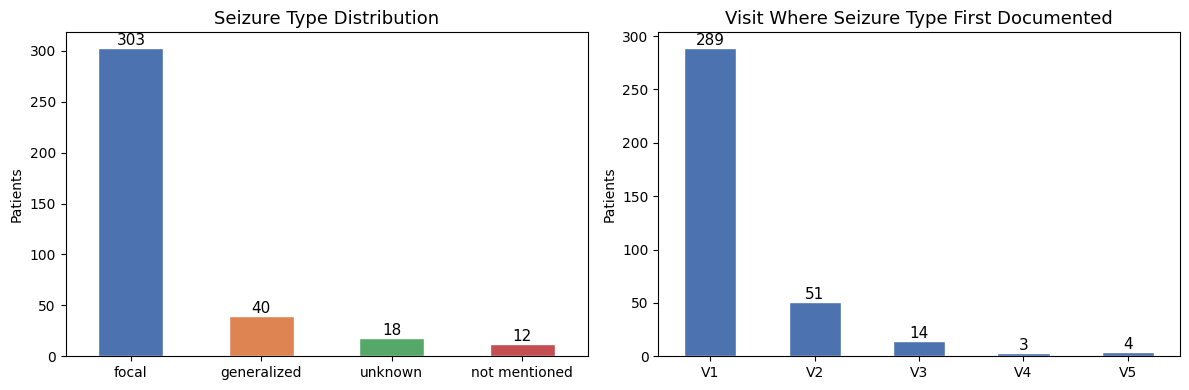

In [3]:
# Extract clean label (focal/generalized/unknown) from value like 'focal (first mentioned: V1)'
def seizure_label(val):
    val = str(val).strip().lower()
    if val.startswith('focal'):       return 'focal'
    if val.startswith('generalized'): return 'generalized'
    if val.startswith('unknown'):     return 'unknown'
    return 'not mentioned'

df['seizure_type_clean'] = df['SeizureType'].apply(seizure_label)

# Extract first-mention visit
def first_visit(val):
    m = re.search(r'V(\d)', str(val))
    return int(m.group(1)) if m else None

df['seizure_first_visit'] = df['SeizureType'].apply(first_visit)

counts = df['seizure_type_clean'].value_counts()
print(counts)
print(f'\nTotal: {len(df)}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#4C72B0', '#DD8452', '#55A868', '#C44E52']
counts.plot.bar(ax=axes[0], color=colors[:len(counts)], edgecolor='white')
axes[0].set_title('Seizure Type Distribution', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Patients')
axes[0].tick_params(axis='x', rotation=0)
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

visit_counts = df[df['seizure_first_visit'].notna()]['seizure_first_visit'].value_counts().sort_index()
visit_counts.index = [f'V{int(v)}' for v in visit_counts.index]
visit_counts.plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Visit Where Seizure Type First Documented', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Patients')
axes[1].tick_params(axis='x', rotation=0)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 2. Age Distribution

Age available: 369 / 373 patients
count    369.0
mean       8.0
std        7.2
min        0.3
25%        3.0
50%        6.0
75%       10.7
max       61.0
Name: age_num, dtype: float64


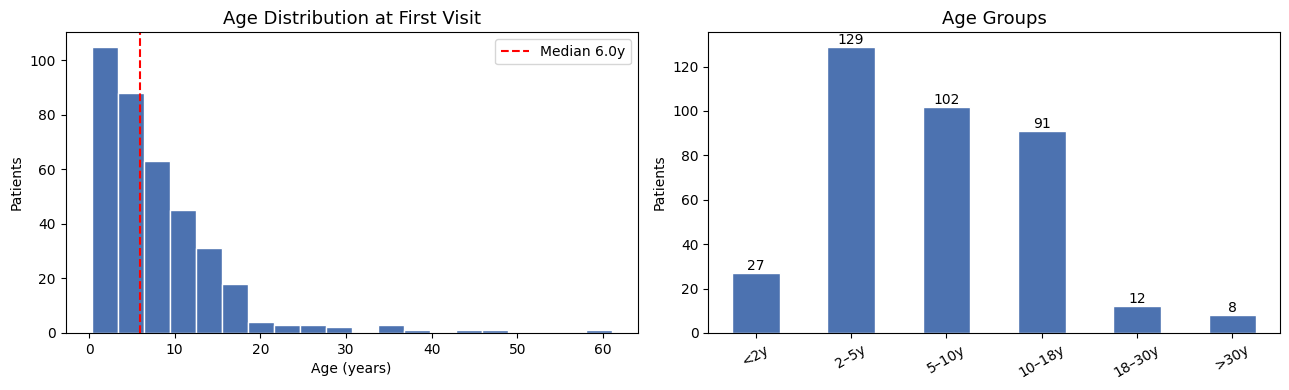

In [4]:
def parse_age(val):
    try:
        return float(str(val).strip())
    except:
        return np.nan

df['age_num'] = df['Age'].apply(parse_age)
age = df['age_num'].dropna()

print(f'Age available: {len(age)} / {len(df)} patients')
print(age.describe().round(1))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(age, bins=20, color='#4C72B0', edgecolor='white')
axes[0].set_title('Age Distribution at First Visit', fontsize=13)
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Patients')
axes[0].axvline(age.median(), color='red', linestyle='--', label=f'Median {age.median():.1f}y')
axes[0].legend()

bins = [0, 2, 5, 10, 18, 30, 200]
labels = ['<2y', '2–5y', '5–10y', '10–18y', '18–30y', '>30y']
df['age_group'] = pd.cut(df['age_num'], bins=bins, labels=labels, right=False)
grp = df['age_group'].value_counts().reindex(labels)
grp.plot.bar(ax=axes[1], color='#4C72B0', edgecolor='white')
axes[1].set_title('Age Groups', fontsize=13)
axes[1].set_xlabel('')
axes[1].set_ylabel('Patients')
axes[1].tick_params(axis='x', rotation=30)
for p in axes[1].patches:
    axes[1].annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 3. Sex Distribution

sex_clean
Male             205
Female           163
Not mentioned      5
Name: count, dtype: int64


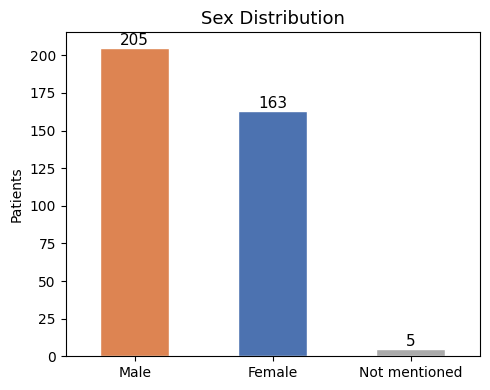

In [5]:
def parse_sex(val):
    v = str(val).strip().lower()
    if v == 'yes':  return 'Female'
    if v == 'no':   return 'Male'
    return 'Not mentioned'

df['sex_clean'] = df['Sex_Female'].apply(parse_sex)
sex_counts = df['sex_clean'].value_counts()
print(sex_counts)

fig, ax = plt.subplots(figsize=(5, 4))
sex_counts.plot.bar(ax=ax, color=['#DD8452', '#4C72B0', '#aaa'], edgecolor='white')
ax.set_title('Sex Distribution', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=0)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=11)
plt.tight_layout()
plt.show()

## 4. Seizure Frequency Trajectory

In [6]:
# Show all trajectory summaries as a table
traj = df[['patient', 'SeizureFreqTrajectory']].copy()
traj = traj[~traj['SeizureFreqTrajectory'].str.lower().str.startswith('not mentioned')]
print(f'{len(traj)} patients have trajectory info')
traj.reset_index(drop=True)

324 patients have trajectory info


,patient,SeizureFreqTrajectory
0,NAKAYIZA_SHARON,Seizure-free throughout all three visits on current regimen.
1,NAKAYEMBA IRENE,Single brief seizure reported at V1; another convulsion reported at V2; no s...
2,KIMULI_YASIR,Seizures reported at V1; seizure‑free reported at V2 and V3.
3,KIRABO HANNAH,Seizure frequency not described at V1 and V2; no seizures reported at V3 and...
4,ASIIMWE_DANIELLA,No recent seizures reported at V1; seizure frequency not described at V2; a ...
...,...,...
319,KIMERA_CHERUBIM,"Seizure reported at V1 (first episode 8 months ago, last episode noted); no ..."
320,NAKAKANDE PEACE,No seizure frequency quantified in V1–V3; reported as seizure‑free (no seizu...
321,SSENYONDO IAN,"V1: single index seizure lasting ~20 minutes (loss of consciousness, jerky m..."
322,SSENTONGO RAHIM,"History of convulsions reported at V1, V2, and V3; seizure‑free reported in ..."


## 5. Risk Factors

perinatal_complication     44
febrile_seizures           35
family_history_epilepsy    12
cerebrovascular_disease     8
trauma_to_head              7
childhood_meningitis        3
cerebral_malaria            2
dtype: int64

No risk factors: 274
Not mentioned:   4


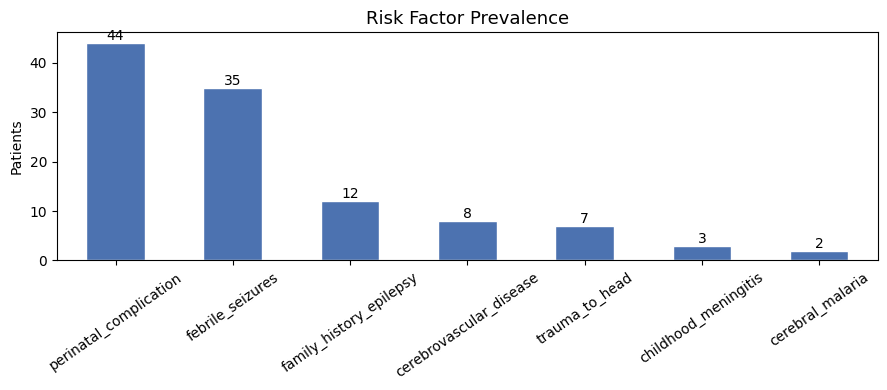

In [7]:
RISK_KEYS = [
    'febrile_seizures', 'childhood_meningitis', 'trauma_to_head',
    'perinatal_complication', 'family_history_epilepsy',
    'cerebral_malaria', 'cerebrovascular_disease',
]

risk_counts = {k: 0 for k in RISK_KEYS}
none_count  = 0

for val in df['RiskFactors']:
    val_l = str(val).lower()
    if 'none mentioned' in val_l:
        none_count += 1
        continue
    for k in RISK_KEYS:
        if k in val_l:
            risk_counts[k] += 1

rf = pd.Series(risk_counts).sort_values(ascending=False)
print(rf)
print(f'\nNo risk factors: {none_count}')
print(f'Not mentioned:   {(df["RiskFactors"].str.lower().str.startswith("not mentioned")).sum()}')

fig, ax = plt.subplots(figsize=(9, 4))
rf.plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Risk Factor Prevalence', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=35)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

## 6. Drug Usage

levetiracetam    212
carbamazepine    184
lamotrigine       99
clobazam          76
valproate         52
phenobarbital     30
topiramate        28
clonazepam         6
phenytoin          2
ethosuximide       0
dtype: int64

Total patients: 373


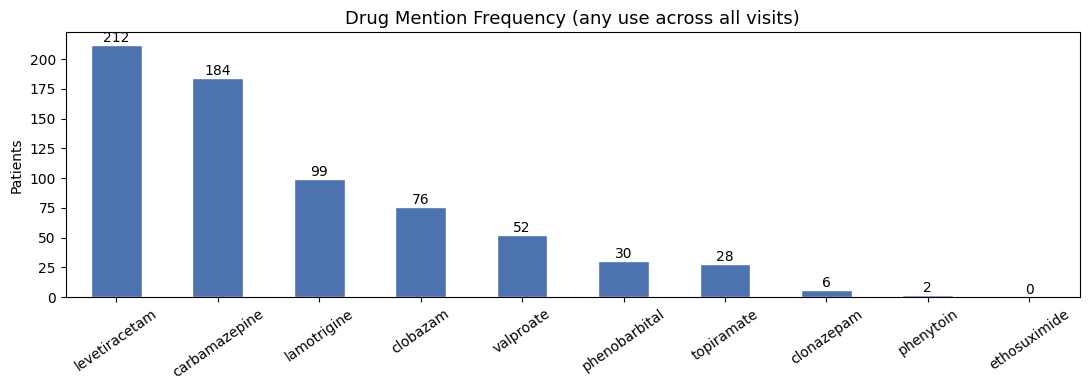

In [8]:
def drug_mentioned(val):
    v = str(val).strip().lower()
    return v != 'not mentioned.' and v != 'not mentioned'

drug_names = [d.replace('drug_', '') for d in DRUGS]
drug_counts = pd.Series(
    {name: df[f'drug_{name}'].apply(drug_mentioned).sum() for name in drug_names}
).sort_values(ascending=False)

print(drug_counts)
print(f'\nTotal patients: {len(df)}')

fig, ax = plt.subplots(figsize=(11, 4))
drug_counts.plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Drug Mention Frequency (any use across all visits)', fontsize=13)
ax.set_xlabel('')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=35)
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width()/2, p.get_height()),
                ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

n_drugs
0      4
1    163
2    126
3     54
4     21
5      3
6      1
7      1
Name: count, dtype: int64

Mean drugs per patient: 1.85


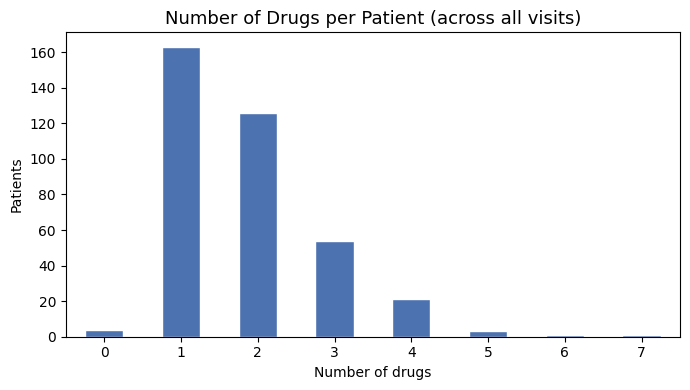

In [9]:
# Number of different drugs per patient
df['n_drugs'] = df[DRUGS].apply(lambda row: sum(drug_mentioned(v) for v in row), axis=1)

print(df['n_drugs'].value_counts().sort_index())
print(f'\nMean drugs per patient: {df["n_drugs"].mean():.2f}')

fig, ax = plt.subplots(figsize=(7, 4))
df['n_drugs'].value_counts().sort_index().plot.bar(ax=ax, color='#4C72B0', edgecolor='white')
ax.set_title('Number of Drugs per Patient (across all visits)', fontsize=13)
ax.set_xlabel('Number of drugs')
ax.set_ylabel('Patients')
ax.tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 7. Seizure Type × Drug Co-occurrence

seizure_type_clean  focal  generalized
levetiracetam         177           22
carbamazepine         165            8
lamotrigine            76           15
clobazam               56           14
valproate              29           18
phenobarbital          25            5
topiramate             23            4
clonazepam              3            1
phenytoin               2            0
ethosuximide            0            0


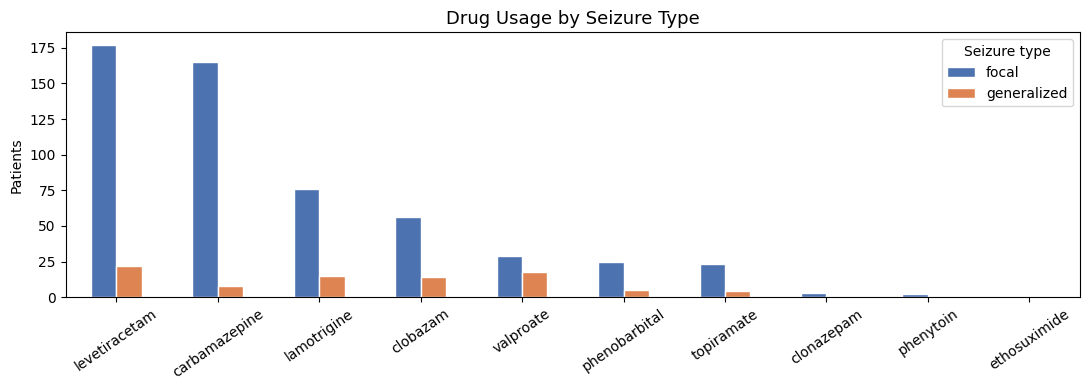

In [10]:
# Which drugs are used in focal vs generalized patients?
sub = df[df['seizure_type_clean'].isin(['focal', 'generalized'])]
drug_by_type = sub.groupby('seizure_type_clean')[DRUGS].apply(
    lambda g: g.apply(lambda col: col.apply(drug_mentioned).sum())
).T
drug_by_type.index = [i.replace('drug_', '') for i in drug_by_type.index]
drug_by_type = drug_by_type.sort_values('focal', ascending=False)

print(drug_by_type)

drug_by_type.plot.bar(figsize=(11, 4), color=['#4C72B0', '#DD8452'], edgecolor='white')
plt.title('Drug Usage by Seizure Type', fontsize=13)
plt.xlabel('')
plt.ylabel('Patients')
plt.xticks(rotation=35)
plt.legend(title='Seizure type')
plt.tight_layout()
plt.show()

## 8. Summary Table

In [11]:
summary = pd.DataFrame({
    'Metric': [
        'Total patients',
        'Age available',
        'Median age (years)',
        'Female',
        'Male',
        'Seizure type: focal',
        'Seizure type: generalized',
        'Seizure type: unknown',
        'Any risk factor mentioned',
        'Most common drug',
        'Patients on ≥2 drugs',
    ],
    'Value': [
        len(df),
        len(age),
        f'{age.median():.1f}',
        (df['sex_clean'] == 'Female').sum(),
        (df['sex_clean'] == 'Male').sum(),
        (df['seizure_type_clean'] == 'focal').sum(),
        (df['seizure_type_clean'] == 'generalized').sum(),
        (df['seizure_type_clean'] == 'unknown').sum(),
        df['RiskFactors'].apply(lambda v: 'none mentioned' not in str(v).lower() and not str(v).lower().startswith('not mentioned')).sum(),
        drug_counts.idxmax(),
        (df['n_drugs'] >= 2).sum(),
    ]
})
summary

,Metric,Value
0,Total patients,373
1,Age available,369
2,Median age (years),6.0
3,Female,163
4,Male,205
5,Seizure type: focal,303
6,Seizure type: generalized,40
7,Seizure type: unknown,18
8,Any risk factor mentioned,95
9,Most common drug,levetiracetam
